# Problems
### Author: Aoife Flavin

## Problem1: Lady Tasting Tea Extended

This experiment is an extension of the Lady Tasting Tea Experiment conducted by Ronald A. Fisher.
In the original instance of the experiment the sample size consists of 8 cups of tea, 4 tea-first and 4 milk-first.

In this notebook I will look at what would happen if the sample size was 12, with 8 cups of tea-first and 4 cups of milk first.

In [8]:
# Mathematical functions from the standard library.
# https://docs.python.org/3/library/math.html
import math

# Permutations and combinations.
# https://docs.python.org/3/library/itertools.html
import itertools

# Random selections.
# https://docs.python.org/3/library/random.html
import random

# Numerical structures and operations.
# https://numpy.org/doc/stable/reference/index.html#reference
import numpy as np

# Plotting.
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

## Recap of 8-Cup Experiment

The original design of the experiment contained 8 cups, with half milk first and half tea-first.

The tea taster knows there are 4 tea-first cups and must decide which they are.
https://www.w3schools.com/python/ref_math_comb.asp

In [9]:
# Total number of cups.
recap_n = 8

# Number of tea-first cups.
recap_k = 4

# Number of different ways to choose 4 cups out of 8.
no_combs_8 = math.comb(recap_n, recap_k)

# Probability of selecting all correct cups by chance
p_all_correct_8 = 1 / no_combs_8

print("Number of combinations (8 cups):", no_combs_8)
print("Probability of all 8 cups being correct by chance:", p_all_correct_8)

Number of combinations (8 cups): 70
Probability of all 8 cups being correct by chance: 0.014285714285714285


## 12-Cup Experiment

For our new experiment we will change the design to use 12 cups in total, 8 of which will have the tea poured first and 4 which will have the milk poured first.

We are assuming the taster knows that 8 of the cups are tea-first and will try to pick out these cups.

#### Label the variables

In [10]:
# Number of cups of tea in total.
no_cups = 12

# Number of cups of tea with milk in first.
cups_milk_first = 4

# Number of cups of tea with tea in first.
cups_tea_first = 8


#### Use Math.comb to find the Probability that randomly all cups would be guessed correctly

Calculate the number of ways to choose k elements from a set of n elements where the order of the chosen elements does not matter and no element is selected more than once.

In [11]:
# Number of ways of selecting four cups from eight.
no_combs_12 = math.comb(no_cups, cups_tea_first)

# Probability of selecting all correct cups by chance
p_all_correct_12 = 1 / no_combs_12

print("Number of combinations (12 cups):", no_combs_12)
print("Probability of all 12 cups being correct by chance:", p_all_correct_12)

Number of combinations (12 cups): 495
Probability of all 12 cups being correct by chance: 0.00202020202020202


### Using NumPy to Simulate Random Guessing

Instead of only using the exact formula, we now simulate the experiment.

This means representing the true cups as a list of labels, where:
  - 1 = tea-first
  - 0 = milk-first

A random guess (under the null hypothesis) can be shown as a random permutation, in this case the participant knows how many tea-first/milk-first cups there are but has no real ability to distinguish them so we shuffle the labels randomly.

For each simulation:
  1. Shuffle the labels to represent a random guess.
  2. Check if the guessed arrangement matches the true arrangement exactly.

Sources:
- https://bookdown.org/kevin_davisross/probsim-book/introduction-to-simulation.html
- https://www.statology.org/how-to-generate-random-numbers-simulations-numpy/
- https://www.kdnuggets.com/numpy-simulating-random-processes-monte-carlo-methods
- https://numpy.org/doc/stable/reference/random/generated/numpy.random.permutation.html


In [12]:
# Define function, true labels = correct arrangement of cups, 1000 simulations
def estimate_all_correct(true_labels, no_sims=1000):
    
    #convert to numpy, start counter
    true_labels = np.array(true_labels)
    count_perfect = 0

    for _ in range(no_sims):
        # random permutation of the labels - null hypothesis
        guess = np.random.permutation(true_labels)

        # Check if all labels are the same as the true ones
        if np.array_equal(guess, true_labels):
            count_perfect += 1

    # amount of simulations with a perfect guess
    return count_perfect / no_sims

# True labels for the each experiment
true_labels_8 = [1]*4 + [0]*4      # 4 tea-first, 4 milk-first
true_labels_12 = [1]*8 + [0]*4     # 8 tea-first, 4 milk-first

# No. simulations
no_sims = 1000

# Estimate probabilities by simulation.
p_all_correct_8_sim = estimate_all_correct(true_labels_8, no_sims)
p_all_correct_12_sim = estimate_all_correct(true_labels_12, no_sims)

print("Simulated probability that all 8 cups are correct: ", p_all_correct_8_sim)
print("Exact     probability that all 8 cups are correct: ", p_all_correct_8)
print()
print("Simulated probability that all 12 cups are correct:", p_all_correct_12_sim)
print("Exact     probability that all 12 cups are correct:", p_all_correct_12)

Simulated probability that all 8 cups are correct:  0.015
Exact     probability that all 8 cups are correct:  0.014285714285714285

Simulated probability that all 12 cups are correct: 0.001
Exact     probability that all 12 cups are correct: 0.00202020202020202


# Interpreting Results

### Null vs Alternative Hypothesis
The Null Hypothesis in this case would mean that the tea taster is just guessing and she has no realy ability to tell the cups apart.

The Alternative Hypothesis would mean that the tea taster is not guessing and she has some ability to tell the cups apart.

**What the probabilities mean**

The Exact probabilities above represent the likelihood of getting a perfect score under the null hypothesis.
- 8-cup design - probability = 1/70 ≈ 0.0143
- 12-cup design - probability = 1/495 ≈ 0.002

**Statistical significance**

A p-value less than 0.05 is typically considered to be statistically significant, in which case the null hypothesis should be rejected

- Both probabilities are below 0.05 → a perfect score rejects the null hypothesis in either design.
- But 1/495 is much smaller than 1/70 → the 12-cup design gives stronger evidence in favor of the alternative hypothesis.

So if the tea taster gets every cup right in the 12-cup setup, it’s stronger evidence that they actually have the skill and are not just guessing.

Sources:
- https://www.investopedia.com/terms/p/p-value.asp 
- https://www.datacamp.com/doc/numpy/arange?dc_referrer=https%3A%2F%2Fwww.google.com%2F
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html


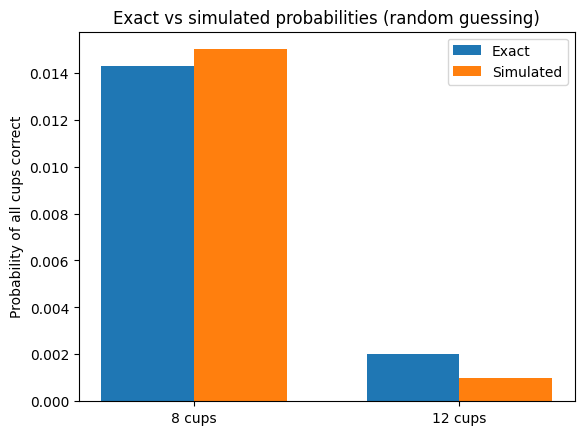

In [13]:
#Bar chart showing probability
labels = ["8 cups", "12 cups"]
exact = [p_all_correct_8, p_all_correct_12]
sim   = [p_all_correct_8_sim, p_all_correct_12_sim]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, exact, width, label="Exact")
ax.bar(x + width/2, sim,   width, label="Simulated")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Probability of all cups correct")
ax.set_title("Exact vs simulated probabilities (random guessing)")
ax.legend();

plt.show()

# Assignment no.2 Normal Distribution

Generate 100,000 samples of size 10 from the standard normal distribution. For each sample, compute the standard deviation with ddof=1 (sample SD) and with ddof=0 (population SD). Plot histograms of both sets of values on the same axes with transparency. Describe the differences you see. Explain how you expect these differences to change if the sample size is increased.

In [14]:
# Binomial distribution.
import numpy as np

# Plotting.
import matplotlib.pyplot as plt

# Statistics.
import scipy.stats as stats

# Statistical models.
import statsmodels as sm

In [15]:
#no of samples (times we repeat the experiment)
no_samples = 100000

# Sample size
s_size = 10

#Standard Normal Distribution
mu = 0
sigma = 1

## Generate the Data

generate all the data in one go as a 2d numpy array

In [19]:
# 100k samples, each of length 10
data = np.random.normal(loc=mu, scale=sigma, size=(no_samples, s_size))

print(data.shape)   # (100000, 10)


(100000, 10)
